# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

### Mushroom Dataset

Podéis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay **muchas variables, todas categóricas**, por lo que las exploraciones con *scatterplot* no nos serán útiles como en otros casos.

La variable a predecir es `class` (`e` = comestible / *edible*, `p` = venenosa / *poisonous*) y es **binaria**.

> En este taller usaremos las etiquetas **solo para validar** lo que descubre el clustering. La idea del aprendizaje no supervisado es encontrar estructura *sin* mirar la etiqueta.

### Algoritmos que cubriremos

**Reducción de dimensionalidad:** PCA (lineal) y t-SNE (no lineal).

**Clustering:** K-Means, Clustering Jerárquico (Aglomerativo), Gaussian Mixture Models (GMM) y DBSCAN.

**Evaluación:** método del codo, *silhouette*, Davies-Bouldin, Calinski-Harabasz y (como tenemos etiqueta) Adjusted Rand Index y NMI.

**Detección de anomalías:** Isolation Forest.

In [44]:
# Carga de librerias, las que hemos considerado basicas, anadid lo que querais :)
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import OneHotEncoder
from scipy.cluster.hierarchy import linkage, dendrogram
import umap
%pip install hdbscan
import hdbscan
%pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Leer conjunto de datos y primer vistazo

In [22]:
# Leer el csv (esta en 'data/mushrooms.csv') y sacar por pantalla las cinco primeras filas.

# Cargamos el dataset. Nota: Todas las variables predictoras son categóricas.
df = pd.read_csv("data/mushrooms.csv")

df.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


### Exploración de datos

In [23]:
# Descripcion del conjunto de datos, estandar.
df.describe(include="all")

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,2,5,4,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,t,b,s,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,3776,5176,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [24]:
# Informacion sobre el tipo de datos de cada feature.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [25]:
#Las dimensiones(filas, columnas).
df.shape

(8124, 23)

In [26]:
# Informacion sobre el tipo de datos de cada feature.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

#### Calcular el número de nulos de cada feature

In [27]:
# Igual que otras veces, una linea: contar los nulos por variable.
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

In [28]:
# Obtener un nuevo dataframe: en una columna las features (feature)
# y en la otra el numero de valores unicos asociados (n_values).
# n_values = ...
n_values = df.nunique().reset_index()
n_values.columns = ["feature", "n_values"]

display(n_values)

# Columnas con un único valor (no aportan información)
print("Columnas con un único valor:")
print(n_values[n_values["n_values"] == 1]["feature"].tolist())

# Columnas que contienen '?'
print("\nColumnas con '?':")
print([col for col in df.columns if "?" in df[col].values])

,feature,n_values
0,class,2
1,cap-shape,6
2,cap-surface,4
3,cap-color,10
4,bruises,2
5,odor,9
6,gill-attachment,2
7,gill-spacing,2
8,gill-size,2
9,gill-color,12


Columnas con un único valor:
['veil-type']

Columnas con '?':
['stalk-root']


Observad dos cosas:
- `veil-type` tiene **un único valor** → no aporta información.
- `stalk-root` contiene el valor `'?'`, que en realidad es un **valor desconocido (nulo encubierto)**.

#### Tratar aquellos valores que entendamos que sean nulos

In [29]:
# Imputaciones. Podeis quitar esos puntos (fila entera), imputar con la moda
# o dejar ese valor como una posibilidad mas. Aqui imputamos '?' con la moda.

# Usumos moda global para stalk-root, como estrategia inicial.
# Nota: en producción un modelo KNN Imputer o una categoría "unknown" mantendría 
# mejor la estructura no supervisada.
df["stalk-root"] = df["stalk-root"].replace("?", np.nan)
df["stalk-root"] = df["stalk-root"].fillna(df["stalk-root"].mode()[0])
print(df["stalk-root"].unique())
print(df["stalk-root"].isna().sum())

['e' 'c' 'b' 'r']
0


#### ¿Todas las features aportan información? Si alguna no aporta, eliminadla

In [30]:
# Dejar por el camino las features con un solo valor (no aportan nada).
cols_constantes = n_values[n_values["n_values"] == 1]["feature"].tolist()
df = df.drop(columns=cols_constantes)
print("Columnas eliminadas:", cols_constantes)
df.shape

Columnas eliminadas: ['veil-type']


(8124, 22)

#### Separar entre variables predictoras y variable a predecir

In [31]:
# La variable a predecir es 'class'.
# y =
y = df["class"]
# X =
X = df.drop(columns="class")
print(X.shape)
print(y.shape)

(8124, 21)
(8124,)


#### Codificar correctamente las variables categóricas a numéricas

In [32]:
# One Hot Encoder (una linea). Pista: pd.get_dummies
X = pd.get_dummies(X)

#### Train / test split

In [33]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto gráficas, así que vamos a hacer algunas. Tenemos muchas variables, **PCA al rescate**: le pedimos dos dimensiones y las pintamos. Serán **las que retengan más información (varianza)**.

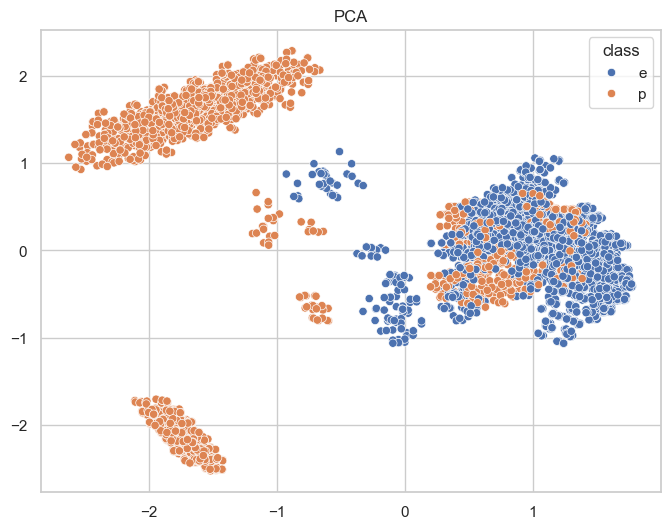

In [34]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)

X_train_pca = pca.fit_transform(X_train)

# Representar en un scatterplot y poner en color las etiquetas de entrenamiento
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_train_pca[:,0],
    y=X_train_pca[:,1],
    hue=y_train
)

plt.title("PCA")
plt.show()

Parece que está bastante separadito, ¡a ojo mucho se puede ver! :)

Antes de seguir, entrenamos un clasificador supervisado como **línea base** (así sabemos cuánta información hay realmente en los datos).

In [35]:
# Definir el clasificador y el numero de estimadores
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

# Entrenar en train
rf.fit(X_train, y_train)

# Calcular la precision sobre test
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("Precision:", acc)

Precision: 1.0


Es un conjunto sencillo y Random Forest es muy bueno. Veamos cuántas features tenemos:

In [36]:
X_train.shape

(5443, 115)

¿Muchas features, no? Vamos a reducirlas con PCA y ver cuántas componentes necesita Random Forest para mantener su precisión.

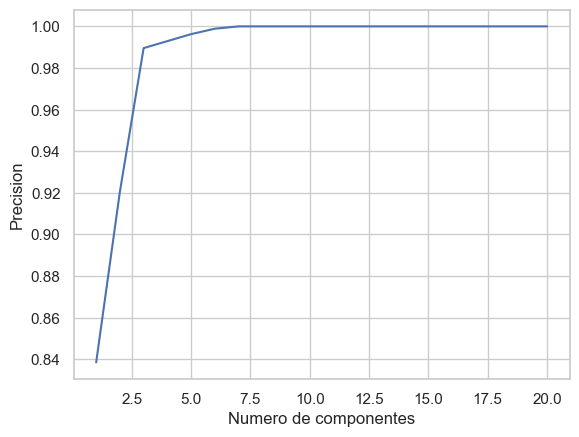

In [37]:
n_features = range(1, 21)  # definir un rango de valores a probar
scores = []

for n in n_features:
    # Definir y ajustar PCA sobre X_train
    pca_n = PCA(n_components=n, random_state=RANDOM_STATE)
    X_train_reducido = pca_n.fit_transform(X_train)
    X_test_reducido = pca_n.transform(X_test)

    # Entrenar Random Forest sobre los datos reducidos
    rf_n = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_n.fit(X_train_reducido, y_train)

    # Guardar el score en test
    pred_n = rf_n.predict(X_test_reducido)
    score_n = accuracy_score(y_test, pred_n)
    scores.append(score_n)

sns.lineplot(x=list(n_features), y=scores)
plt.xlabel("Numero de componentes")
plt.ylabel("Precision")
plt.show()


A partir de ~10 componentes ya tenemos la precisión que queríamos, reduciendo las variables a una fracción de las originales.

---
## t-SNE: reducción **no lineal** para visualizar

PCA es lineal. **t-SNE** intenta preservar la vecindad local y suele separar mejor los grupos visualmente. Es más caro, así que lo calculamos sobre una **muestra**.

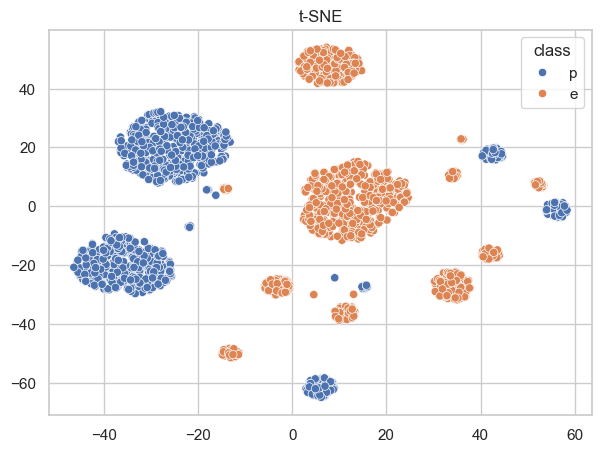

In [38]:
# Tomar una muestra de X_train (t-SNE es lento)
X_muestra = X_train.sample(n=2000, random_state=RANDOM_STATE)
y_muestra = y_train.loc[X_muestra.index]

# Definir TSNE(n_components=2, ...) y ajustar
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_muestra)

# Pintar el embedding coloreado por la etiqueta
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_muestra)
plt.title("t-SNE")
plt.show()

---
## Clustering

El conjunto es sencillito, así que probemos clustering para ver qué información obtenemos **sin usar las etiquetas**. Trabajaremos sobre una representación reducida con PCA (10 componentes), que limpia ruido y acelera los algoritmos.

In [39]:
# Reducir X (one-hot completo) a 10 componentes con PCA -> X_red
pca_10 = PCA(n_components=10, random_state=RANDOM_STATE)
X_red = pca_10.fit_transform(X)
X_red.shape

(8124, 10)

### K-Means: ¿cuántos clusters? Codo + Silhouette

El **método del codo** mira la inercia (suma de distancias a los centroides). El **coeficiente de silhouette** mide cómo de bien separados están los clusters (cuanto más alto, mejor). Usamos ambos.

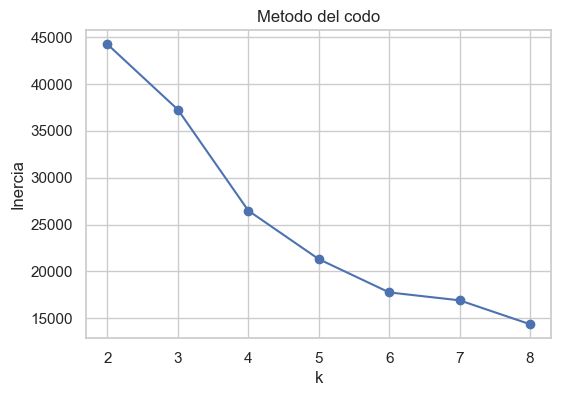

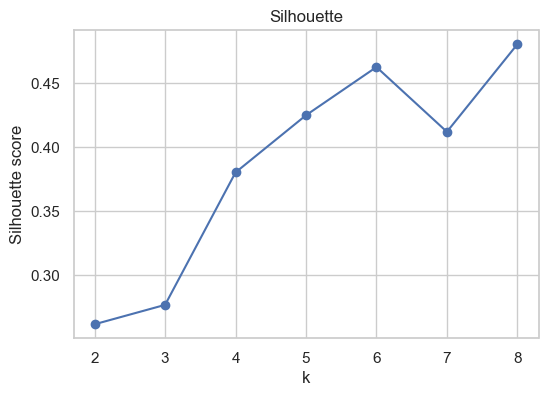

In [40]:
from sklearn.cluster import KMeans

k_values = range(2, 9) # definir un rango
inercias, silhouettes = [], []

for k in k_values:
    # Definir KMeans y ajustar sobre X_red    
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    etiquetas = modelo.fit_predict(X_red)

    # Guardar la inercia (km.inertia_) y el silhouette_score    
    inercias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(X_red, etiquetas))

# Pintar las dos curvas (codo y silhouette)
plt.figure(figsize=(6, 4))
plt.plot(list(k_values), inercias, marker="o")
plt.title("Metodo del codo")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(list(k_values), silhouettes, marker="o")
plt.title("Silhouette")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.show()

### K-Means final y comparación con la etiqueta

Sabemos que hay dos clases (comestible / venenosa), así que probamos `k=2`. Con `catplot` vemos la distribución de la etiqueta real dentro de cada cluster.

ARI: 0.6170564946596258
NMI: 0.566282507939517


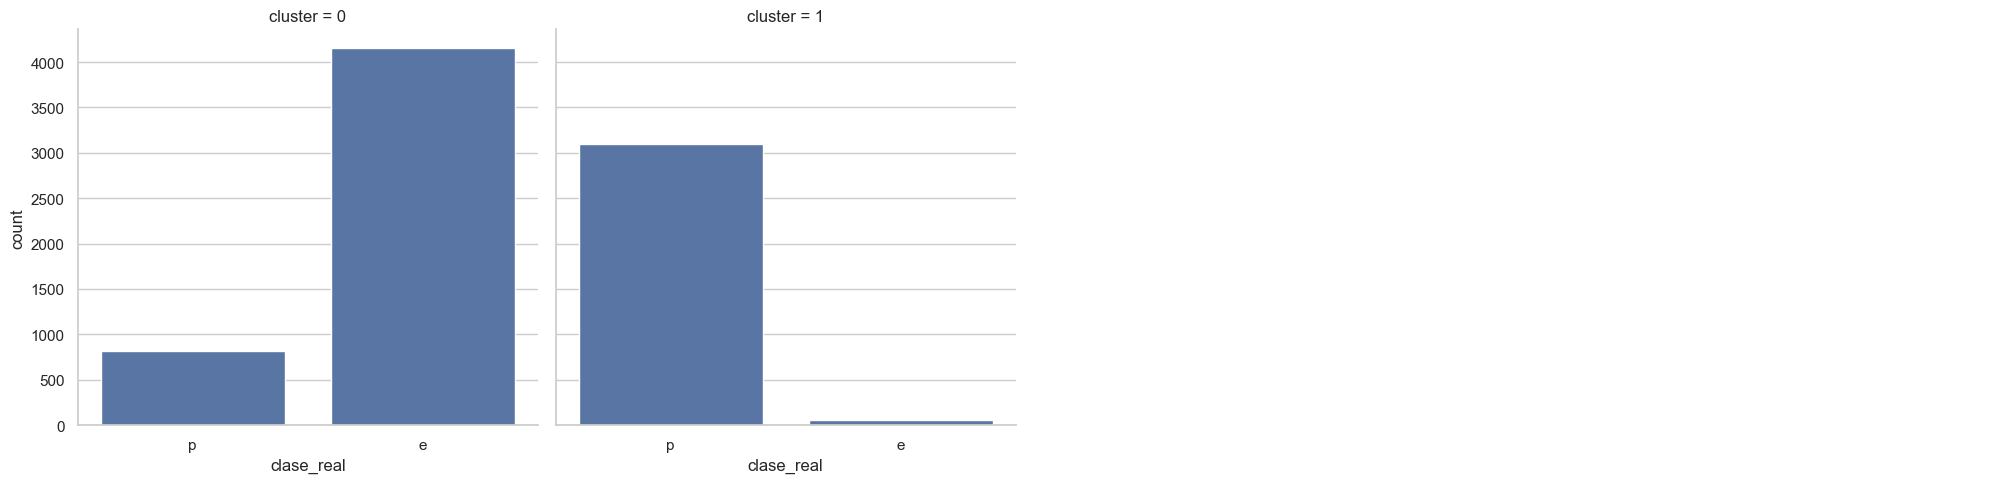

In [41]:
# Aprender KMeans con el k obtenido y preparar el catplot.
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE)  # Definir y entrenar KMeans
cluster_labels = kmeans.fit_predict(X_red)

# ax = sns.catplot(col=, x=, data=, kind='count', col_wrap=4)
y_bin = y 
df_plot = pd.DataFrame()
df_plot["cluster"] = cluster_labels
df_plot["clase_real"] = y_bin

ax = sns.catplot(col="cluster", x="clase_real", data=df_plot, kind="count", col_wrap=4)

# Calcular ARI y NMI frente a y_bin
ari = adjusted_rand_score(y_bin, cluster_labels)
nmi = normalized_mutual_info_score(y_bin, cluster_labels)

print("ARI:", ari)
print("NMI:", nmi)

> **ARI / NMI** comparan los clusters con la etiqueta real (0 = aleatorio, 1 = idéntico). Sin haber visto la etiqueta, K-Means recupera buena parte de la estructura comestible/venenosa, pero **no es perfecto**: ese es el reto real del no supervisado.

### Comparativa de algoritmos de clustering

Vamos a poner a competir **K-Means, Aglomerativo, GMM y DBSCAN** con varias métricas. Las tres primeras métricas son *internas* (no usan etiqueta); ARI sí la usa, para validar.

In [42]:
# Definir una funcion evaluar(nombre, labels, X) que devuelva silhouette,
# davies_bouldin, calinski_harabasz y ARI.
def evaluar(nombre, labels, X):
    resultado = {}
    resultado["algoritmo"] = nombre
    resultado["silhouette"] = silhouette_score(X, labels)
    resultado["davies_bouldin"] = davies_bouldin_score(X, labels)
    resultado["calinski_harabasz"] = calinski_harabasz_score(X, labels)
    resultado["ARI"] = adjusted_rand_score(y_bin, labels)
    return resultado

lista_resultados = []

# Aplicarla a KMeans, AgglomerativeClustering, GaussianMixture y DBSCAN
# KMeans
modelo_km = KMeans(n_clusters=2, random_state=RANDOM_STATE)
etiquetas_km = modelo_km.fit_predict(X_red)
lista_resultados.append(evaluar("KMeans", etiquetas_km, X_red))

# Aglomerativo
modelo_agg = AgglomerativeClustering(n_clusters=2)
etiquetas_agg = modelo_agg.fit_predict(X_red)
lista_resultados.append(evaluar("Aglomerativo", etiquetas_agg, X_red))

# GMM
modelo_gmm = GaussianMixture(n_components=2, random_state=RANDOM_STATE)
etiquetas_gmm = modelo_gmm.fit_predict(X_red)
lista_resultados.append(evaluar("GMM", etiquetas_gmm, X_red))

# DBSCAN
modelo_db = DBSCAN(eps=1.5, min_samples=10)
etiquetas_db = modelo_db.fit_predict(X_red)
lista_resultados.append(evaluar("DBSCAN", etiquetas_db, X_red))

# y montar una tabla (DataFrame) comparativa.
tabla = pd.DataFrame(lista_resultados)
tabla

,algoritmo,silhouette,davies_bouldin,calinski_harabasz,ARI
0,KMeans,0.261416,1.692939,2564.691274,0.617056
1,Aglomerativo,0.258872,1.696264,2503.624971,0.608952
2,GMM,0.257873,1.700914,2500.017463,0.598621
3,DBSCAN,0.357992,1.070795,2304.340409,0.373645


### Dendrograma (clustering jerárquico)

El clustering aglomerativo construye una jerarquía que podemos visualizar como **dendrograma**. La altura a la que se unen dos grupos indica cómo de distintos son. Lo calculamos sobre una muestra para que se lea bien.

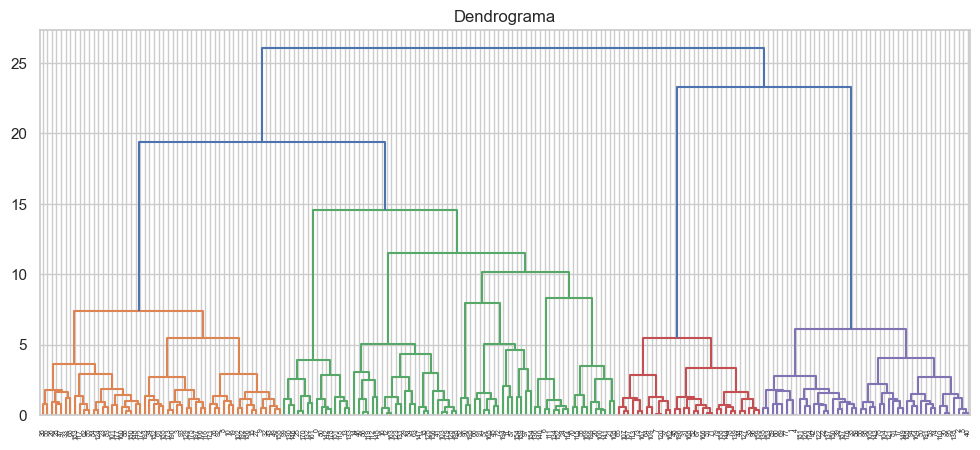

In [45]:
# Tomar una muestra de X_red
np.random.seed(RANDOM_STATE)
indices_muestra = np.random.choice(len(X_red), size=200, replace=False)
X_muestra = X_red[indices_muestra]

# linkage(..., method='ward')
Z = linkage(X_muestra, method="ward")

# dendrogram(...) para visualizar la jerarquia
plt.figure(figsize=(12, 5))
dendrogram(Z)
plt.title("Dendrograma")
plt.show()

### DBSCAN: la **métrica de distancia importa**

DBSCAN agrupa por densidad. Pero con datos **categóricos** codificados en one-hot, la distancia euclídea no captura bien la similitud. Comparemos euclídea (sobre PCA) con la distancia de **Jaccard** (pensada para datos binarios).

In [46]:
# Comparar DBSCAN con metric='euclidean' (sobre X_red) y metric='jaccard'
# (sobre el one-hot binario). Observar cual recupera mejor la estructura (ARI).

# euclidean
modelo_euclid = DBSCAN(eps=1.5, min_samples=10, metric="euclidean")
etiquetas_euclid = modelo_euclid.fit_predict(X_red)

num_clusters_euclid = len(set(etiquetas_euclid)) - (1 if -1 in etiquetas_euclid else 0)
num_ruido_euclid = list(etiquetas_euclid).count(-1)

print("--- Euclidea ---")
print("Clusters encontrados:", num_clusters_euclid)
print("Puntos de ruido:", num_ruido_euclid)
print("ARI:", adjusted_rand_score(y_bin, etiquetas_euclid))

--- Euclidea ---
Clusters encontrados: 6
Puntos de ruido: 0
ARI: 0.37364464459063235


In [ ]:
# jaccard
modelo_jaccard = DBSCAN(eps=0.3, min_samples=10, metric="jaccard")
etiquetas_jaccard = modelo_jaccard.fit_predict(X.astype(bool))

num_clusters_jaccard = len(set(etiquetas_jaccard)) - (1 if -1 in etiquetas_jaccard else 0)
num_ruido_jaccard = list(etiquetas_jaccard).count(-1)

print("\n--- Jaccard ---")
print("Clusters encontrados:", num_clusters_jaccard)
print("Puntos de ruido:", num_ruido_jaccard)
print("ARI:", adjusted_rand_score(y_bin, etiquetas_jaccard))


--- Jaccard ---
Clusters encontrados: 1
Puntos de ruido: 0
ARI: 0.0


> **Lección:** con datos categóricos, elegir la distancia adecuada (Jaccard/Hamming) puede cambiar por completo el resultado de un algoritmo basado en densidad. No hay un algoritmo que gane siempre: depende del tipo de datos.

### Visualización final: clusters vs etiqueta real

Repetimos el scatter PCA, pero coloreando por el cluster de K-Means y por la etiqueta real, lado a lado.

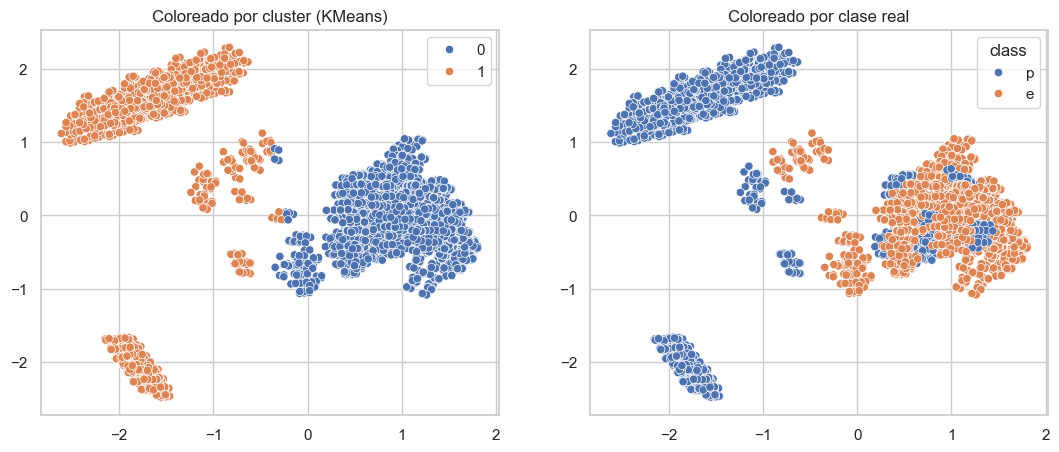

In [ ]:
# Entrenar PCA(2) sobre X para representar.
pca_final = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_final = pca_final.fit_transform(X_red)

# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=cluster_labels, ax=ejes[0])
ejes[0].set_title("Coloreado por cluster (KMeans)")

sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=y_bin, ax=ejes[1])
ejes[1].set_title("Coloreado por clase real")

plt.show()

Es bastante parecido, ¿no? No es tan bueno como Random Forest (que usa etiquetas), pero K-Means ha identificado bastante bien la estructura **sin usarlas**. Si no tuviéramos etiquetas, esta aproximación nos ayudaría mucho a clasificar los tipos de hongos.

---
## Detección de anomalías (Isolation Forest)

Una tarea no supervisada distinta: encontrar las muestras **atípicas**. Isolation Forest aísla los puntos raros con pocos cortes aleatorios.

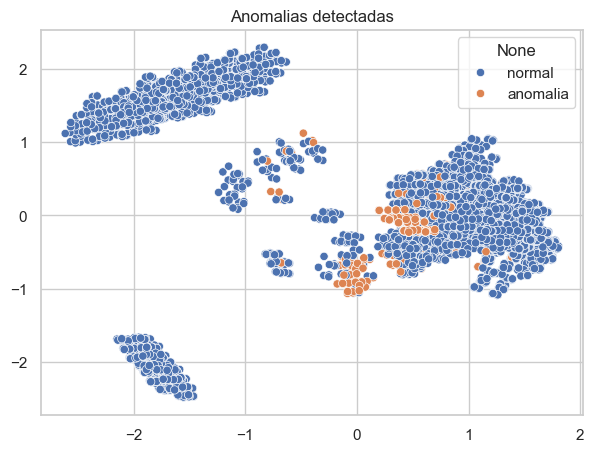

Numero de anomalias: 407


In [ ]:
# Definir IsolationForest(contamination=...) y ajustar sobre X_red
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)

# predict -> -1 son anomalias
anomaly_labels = iso.fit_predict(X_red)

# Pintarlas sobre la proyeccion PCA
plt.figure(figsize=(7, 5))
colores = pd.Series(anomaly_labels).map({1: "normal", -1: "anomalia"})
sns.scatterplot(x=X_pca_final[:, 0], y=X_pca_final[:, 1], hue=colores)
plt.title("Anomalias detectadas")
plt.show()

print("Numero de anomalias:", list(anomaly_labels).count(-1))

---
## Para ir más allá (opcional)

- **UMAP** (`pip install umap-learn`): alternativa a t-SNE, más rápida y preserva mejor la estructura global.

c:\Users\Usuario\Desktop\bootcamp-da-p2\project08_DA-project-classification_Grupo4\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


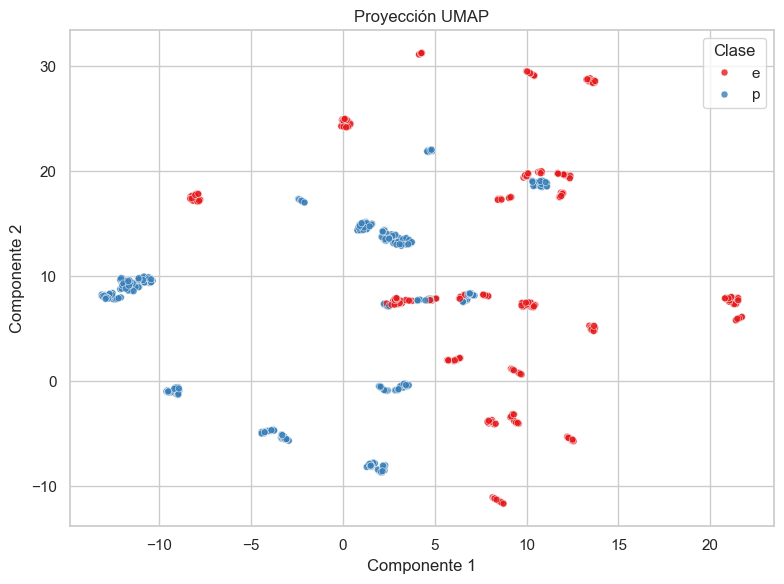

In [ ]:
# Seleccionar una muestra
idx = np.random.choice(len(X_red), 1000, replace=False)

X_sample = X_red[idx]
y_sample = y.reset_index(drop=True).iloc[idx]

# Crear el modelo UMAP
umap_model = umap.UMAP(
    n_components=2,          # Reducimos a 2 dimensiones
    n_neighbors=15,          # Número de vecinos considerados
    min_dist=0.2,            # Distancia mínima entre puntos
    metric="euclidean",      # Métrica de distancia
    random_state=RANDOM_STATE
)

# Ajustar y transformar
X_umap = umap_model.fit_transform(X_sample)

# Representación gráfica
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=y_sample,
    palette="Set1",
    s=25,
    alpha=0.8
)

plt.title("Proyección UMAP")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(title="Clase")
plt.tight_layout()

plt.show()

- **HDBSCAN** (`pip install hdbscan`): DBSCAN jerárquico que no necesita fijar `eps`.

In [ ]:
# Creamos el modelo HDBSCAN (min_cluster_size es el parametro mas importante a ajustar)
modelo_hdbscan = hdbscan.HDBSCAN(min_cluster_size=50)

# Lo entrenamos sobre los datos reducidos con PCA (X_red)
etiquetas_hdbscan = modelo_hdbscan.fit_predict(X_red)

# Contamos cuantos clusters y cuanto ruido encontro
num_clusters_hdbscan = len(set(etiquetas_hdbscan)) - (1 if -1 in etiquetas_hdbscan else 0)
num_ruido_hdbscan = list(etiquetas_hdbscan).count(-1)

print("Clusters encontrados:", num_clusters_hdbscan)
print("Puntos de ruido:", num_ruido_hdbscan)
print("ARI:", adjusted_rand_score(y_bin, etiquetas_hdbscan))

Clusters encontrados: 22
Puntos de ruido: 689
ARI: 0.1617642768770196


- **Reglas de asociación** (`mlxtend`, Apriori/FP-Growth): muy naturales aquí por ser datos categóricos; permiten descubrir reglas tipo «si olor = X entonces venenosa».

In [ ]:
# Construimos un dataframe one-hot que incluya tambien la clase (comestible/venenosa)
df_rules = X.sample(2000, random_state=RANDOM_STATE)

# Buscamos conjuntos de items frecuentes (que aparezcan en al menos el 10% de los casos)
frecuentes = apriori(df_rules, min_support=0.1, use_colnames=True, max_len=2)

# Extraemos las reglas de asociacion con una confianza minima del 80%
reglas = association_rules(frecuentes, metric="confidence", min_threshold=0.8)


# Ordenamos por confianza y mostramos las mas fuertes
reglas = reglas.sort_values("lift", ascending=False)

reglas.head(7)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
264,(ring-type_l),(spore-print-color_h),0.1640,0.2055,0.1640,1.000000,4.866180,1.0,0.130298,inf,0.950359,0.798054,1.000000,0.899027
74,(ring-type_l),(odor_f),0.1640,0.2680,0.1640,1.000000,3.731343,1.0,0.120048,inf,0.875598,0.611940,1.000000,0.805970
75,(spore-print-color_h),(odor_f),0.2055,0.2680,0.2000,0.973236,3.631478,1.0,0.144926,27.350182,0.912058,0.731261,0.963437,0.859752
216,(ring-type_l),(stalk-surface-below-ring_k),0.1640,0.2875,0.1640,1.000000,3.478261,1.0,0.116850,inf,0.852273,0.570435,1.000000,0.785217
170,(gill-color_b),(spore-print-color_w),0.2115,0.2885,0.2115,1.000000,3.466205,1.0,0.150482,inf,0.902346,0.733102,1.000000,0.866551
207,(ring-type_l),(stalk-surface-above-ring_k),0.1640,0.2905,0.1640,1.000000,3.442341,1.0,0.116358,inf,0.848684,0.564544,1.000000,0.782272
160,(gill-color_b),(gill-size_n),0.2115,0.3190,0.2115,1.000000,3.134796,1.0,0.144031,inf,0.863665,0.663009,1.000000,0.831505


## Conclusiones

- PCA y t-SNE nos dejaron *ver* un dataset de >100 dimensiones.
- K-Means, GMM y Aglomerativo recuperan la estructura comestible/venenosa con ARI ~0.6 **sin usar la etiqueta**.
- DBSCAN nos enseñó que **la métrica de distancia importa** con datos categóricos.
- Isolation Forest localiza las setas más atípicas.
- El no supervisado no da una respuesta «perfecta», pero descubre estructura muy útil cuando no tenemos etiquetas.